SMS Spam Detection Using SVM

Import libraries

In [107]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load dataset

In [108]:
df = pd.read_csv("data/spam.csv", encoding='latin-1')

print(df.head())
print(df.info())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB

Cleaning, preprocessing

In [ ]:
# remove unnecessary columns
df = df[['v1', 'v2']]

# rename columns
df.columns = ['label', 'message']

# show cleaned dataframe
print(df.head())

# check class distribution
print(df['label'].value_counts())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label
ham     4825
spam     747
Name: count, dtype: int64


Label encoding and train-test split

In [ ]:
from sklearn.model_selection import train_test_split

# convert labels to numbers
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())

# features and targets
X = df['message']
y = df['label']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
Training samples: 4457
Test samples: 1115


Text vectorization using CountVectorizer

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# create vectorizer
vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=3
)

# learn vocabulary from training data
X_train_vec = vectorizer.fit_transform(X_train)

# transform test data using same vocabulary
X_test_vec = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_vec.shape)
print("Test matrix shape:", X_test_vec.shape)

Training matrix shape: (4457, 6283)
Test matrix shape: (1115, 6283)


Model training completed.
Accuracy: 0.9838565022421525

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115


Confusion Matrix:
[[964   2]
 [ 16 133]]


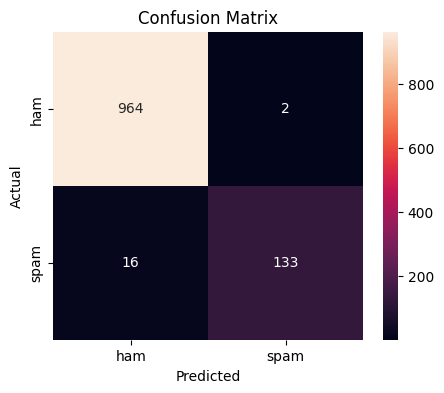

In [ ]:
from sklearn.svm import LinearSVC

# create SVM model
svm_model = LinearSVC(random_state=42, class_weight="balanced", max_iter=10000)

# train model
svm_model.fit(X_train_vec, y_train)

print("Model training completed.")

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# predict on test data
y_pred = svm_model.predict(X_test_vec)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

# confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=[0,1])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Error analysis

In [ ]:
# show misclassified messages from the model
misclassified_df = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": y_pred
})

# Keep only wrongly classified messages
misclassified_df = misclassified_df[
    misclassified_df["actual"] != misclassified_df["predicted"]
]

# convert numeric labels back to text
misclassified_df["actual"] = misclassified_df["actual"].map({0: "ham", 1: "spam"})
misclassified_df["predicted"] = misclassified_df["predicted"].map({0: "ham", 1: "spam"})

print("Number of misclassified messages:", len(misclassified_df))

# display first 10 misclassified messages
misclassified_df.head(30)

Number of misclassified messages: 18


,message,actual,predicted
5,FreeMsg Hey there darling it's been 3 week's n...,spam,ham
573,Waiting for your call.,ham,spam
3979,ringtoneking 84484,spam,ham
3358,Sorry I missed your call let's talk when you h...,spam,ham
5449,"Latest News! Police station toilet stolen, cop...",spam,ham
4614,Sunshine Quiz! Win a super Sony DVD recorder i...,spam,ham
1459,Bought one ringtone and now getting texts cost...,spam,ham
1268,Can U get 2 phone NOW? I wanna chat 2 set up m...,spam,ham
1939,More people are dogging in your area now. Call...,spam,ham
1429,For sale - arsenal dartboard. Good condition b...,spam,ham


Compare other model's performance such as Decision Tree, Random Forest, Logistic Regression and Naive Bayes

                 Model  Precision    Recall
0        Decision Tree   0.888112  0.852349
1        Random Forest   1.000000  0.805369
2          Naive Bayes   0.964029  0.899329
3  Logistic Regression   0.992308  0.865772
4           Linear SVM   0.992593  0.899329


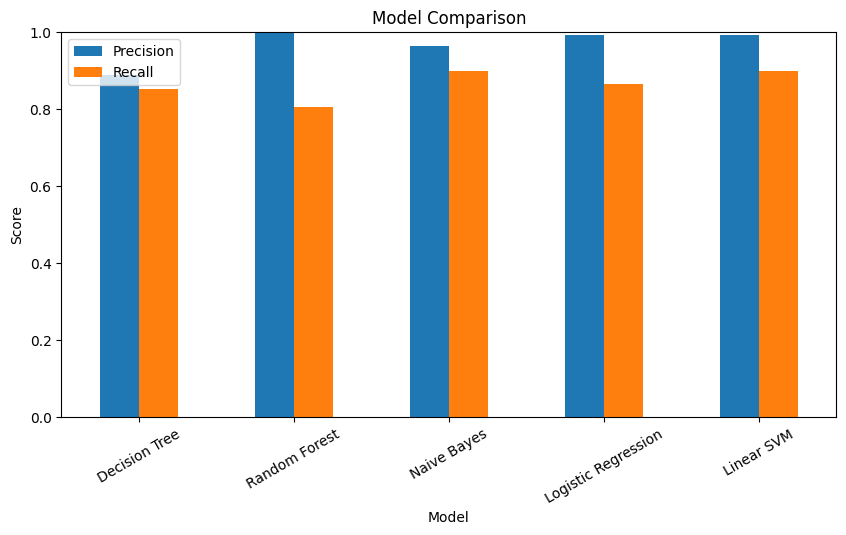

In [114]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42)
}

results = []

for model_name, model in models.items():
    model.fit(X_train_vec, y_train)
    predictions = model.predict(X_test_vec)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)


    results.append([model_name, precision, recall])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Precision", "Recall"]
)

print(results_df)
results_df.plot(
    x="Model",
    y=["Precision", "Recall"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()